> **This is a research notebook — one of seven, one per section of the paper.**
>
> For the presentation version, read the two self-contained notebooks in
> [`final/`](../final/) instead: [`1_information_bottleneck.ipynb`](../final/1_information_bottleneck.ipynb) (the whole argument, end to end) and [`2_transformer_extension.ipynb`](../final/2_transformer_extension.ipynb).
>
> This one is the deep dive on the replication itself, plus the KDE and Kraskov estimators and appendices B, C, E.

# 2 — Replicating Shwartz-Ziv & Tishby, and breaking the result with one line

**Reproduces:** paper section 2 (figures 1A–B) and appendices A, B, C, E.

---

Notebook 1 predicted, from an exactly solvable one-neuron model, that

* a **double-saturating** nonlinearity produces a compression phase once its weights grow,
* a **single-sided or unbounded** one never does,

and that both statements are about the binning assumption, not about learning. This
notebook checks the prediction on the actual network and dataset of Shwartz-Ziv & Tishby
(2017).

## The setup

* **Data.** 12 binary inputs, so $2^{12} = 4096$ patterns, each appearing exactly once,
  with a binary label ($P(Y{=}1) \approx 0.517$). This is the authors' own `var_u.mat`.
  Because the input alphabet is *finite and fully enumerated*, taking it uniform gives
  $H(X) = \log_2 4096 = 12$ bits **exactly**, and binning-based mutual information over all
  4096 patterns has no sampling error.
* **Network.** 12–10–7–5–4–3–2, seven fully connected layers, final layer two sigmoidal
  units. Trained by SGD on 80% of the patterns, 256 samples per batch.
* **Measurement.** Each neuron's activity is binned into 30 equal intervals on $[-1,1]$
  (tanh) or 100 intervals spanning the extremes ever observed (ReLU); the layer's symbol is
  the *joint* bin pattern across its neurons.

The only thing that changes between the two headline runs is the string `"tanh"` → `"relu"`.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ibdl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ibdl import plotting
plotting.use_paper_style()
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root:", ROOT)

project root: /home/hooman/Desktop/InfoTheory/Project


In [2]:
from ibdl.cache import cached
from ibdl.data import load_tishby
from ibdl.experiments import TishbyConfig, run_tishby, relu_binning_bounds
from ibdl.planes import tishby_plane, tishby_plane_averaged, kraskov_entropy_curve

train_set, test_set, full = load_tishby()
labels = full.y

print(f"patterns      : {len(full)}  (all {2**12} twelve-bit strings, each once)")
print(f"H(X)          : {np.log2(len(full)):.1f} bits (uniform over the patterns)")
p1 = labels.mean()
H_Y = -(p1 * np.log2(p1) + (1 - p1) * np.log2(1 - p1))
print(f"P(Y=1)        : {p1:.4f}")
print(f"H(Y)          : {H_Y:.4f} bits  <- the ceiling for I(T;Y)")
print(f"train / test  : {len(train_set)} / {len(test_set)}")

patterns      : 4096  (all 4096 twelve-bit strings, each once)
H(X)          : 12.0 bits (uniform over the patterns)
P(Y=1)        : 0.5171
H(Y)          : 0.9992 bits  <- the ceiling for I(T;Y)
train / test  : 3277 / 819


## 2.1 Train the two networks

Identical in every respect except the hidden nonlinearity. (Results are cached; the first
run trains them, which takes a couple of minutes each.)

In [3]:
cfg_tanh = TishbyConfig(activation="tanh", seed=0, track_grad_snr=True)
cfg_relu = TishbyConfig(activation="relu", seed=0, track_grad_snr=True)

log_tanh = cached(cfg_tanh.tag, lambda: run_tishby(cfg_tanh))
log_relu = cached(cfg_relu.tag, lambda: run_tishby(cfg_relu))

for name, log in [("tanh", log_tanh), ("relu", log_relu)]:
    print(f"{name}: train acc {log.train_acc[-1]:.3f}  test acc {log.test_acc[-1]:.3f}  "
          f"train loss {log.train_loss[-1]:.4f}  ({len(log.epochs)} checkpoints, "
          f"{log.epochs[-1]} epochs)")

[cache] loaded 'tishby_tanh_sgd256_lr0.004_e10000_f0.8_s0' (37.3 MB)
[cache] loaded 'tishby_relu_sgd256_lr0.004_e10000_f0.8_s0' (17.8 MB)
tanh: train acc 0.981  test acc 0.962  train loss 0.0350  (80 checkpoints, 10000 epochs)
relu: train acc 0.987  test acc 0.973  train loss 0.0301  (80 checkpoints, 10000 epochs)


### Appendix A — both networks learn the task

Before reading anything into the information plane, confirm that the two networks are
comparable learners. They are: both generalise well, with test accuracy tracking train.

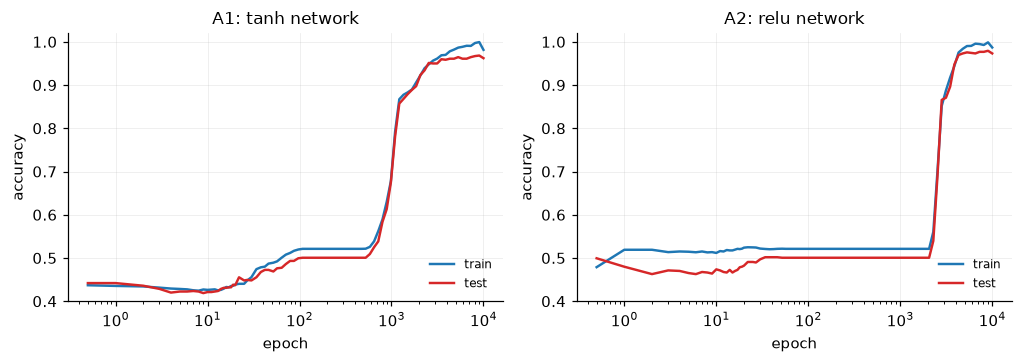

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4))
for ax, (name, log) in zip(axes, [("tanh", log_tanh), ("relu", log_relu)]):
    x = np.maximum(log.epochs, 0.5)
    ax.plot(x, log.train_acc, label="train", color="#1f77b4")
    ax.plot(x, log.test_acc, label="test", color="#d62728")
    ax.set_xscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
    ax.set_title(f"A{1 if name == 'tanh' else 2}: {name} network")
    ax.set_ylim(0.4, 1.02)
    ax.legend(loc="lower right")
fig.tight_layout()
plotting.save(fig, "figA1_learning_curves", FIGDIR)
plt.show()

## 2.2 Figures 1A and 1B — the headline result

Reading the information plane: each layer traces one curve, coloured by epoch. The input
layer sits at the far **right** (it knows the most about $X$), the output layer at the far
**left**. Movement **right and up** is fitting; movement **left** is compression.

The binning protocol differs between the two networks only because their ranges differ:
tanh is bounded in $[-1,1]$ so we use 30 bins there; ReLU is unbounded, so following
appendix C we train first, find the largest activity ever produced, and use 100 equally
spaced bins over that range (equivalent to infinitely many equally spaced bins, since bins
past the observed maximum are never occupied).

In [5]:
# tanh: 30 bins evenly spaced on [-1, 1] (paper section 2)
# relu: 100 bins spanning the extremes observed over training (appendix C)
# tishby_plane() picks the right protocol from the activation's range and caches
# the estimated plane separately from the training run.
plane_tanh = tishby_plane(cfg_tanh, labels, estimator="binning")
plane_relu = tishby_plane(cfg_relu, labels, estimator="binning")
ixt_tanh, ity_tanh = plane_tanh.I_XT, plane_tanh.I_TY
ixt_relu, ity_relu = plane_relu.I_XT, plane_relu.I_TY

lo, hi = relu_binning_bounds(log_relu)
print(f"tanh binning : 30 bins on [-1, 1]")
print(f"ReLU binning : 100 bins on [{lo:.3f}, {hi:.3f}]  (extremes over all training)")

tanh binning : 30 bins on [-1, 1]
ReLU binning : 100 bins on [0.000, 56.306]  (extremes over all training)


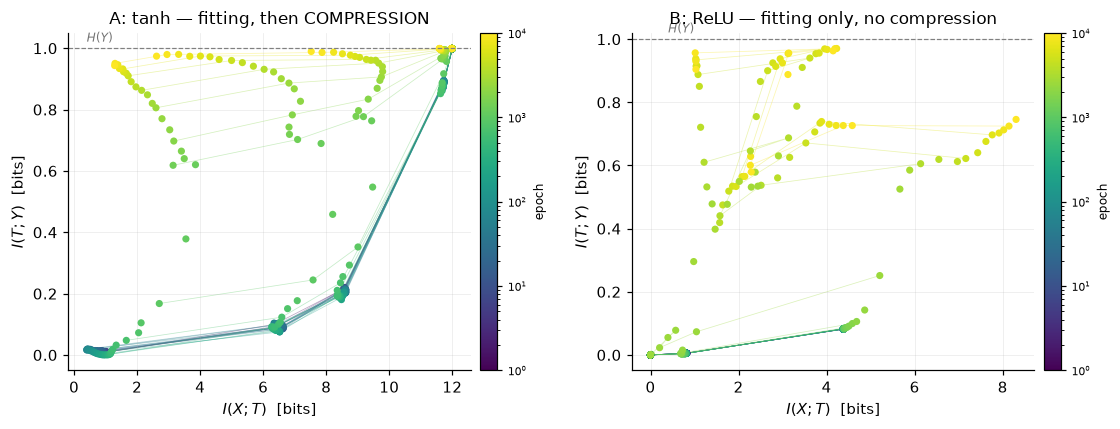

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
plotting.information_plane(
    log_tanh.epochs, ixt_tanh, ity_tanh, ax=axes[0],
    title="A: tanh — fitting, then COMPRESSION", layer_names=log_tanh.layer_names)
plotting.information_plane(
    log_relu.epochs, ixt_relu, ity_relu, ax=axes[1],
    title="B: ReLU — fitting only, no compression", layer_names=log_relu.layer_names)
for ax in axes:
    ax.axhline(H_Y, ls="--", lw=0.8, color="0.5")
    ax.text(0.4, H_Y + 0.02, r"$H(Y)$", fontsize=8, color="0.45")
fig.tight_layout()
plotting.save(fig, "fig01AB_information_plane", FIGDIR)
plt.show()

In [7]:
def compression_table(name, ixt, log):
    print(f"\n{name} network")
    print(f"{'layer':12s} {'I(X;T) init':>12s} {'peak':>8s} {'final':>8s} "
          f"{'drop from peak':>15s}")
    print("-" * 60)
    for j, ln in enumerate(log.layer_names):
        x = ixt[:, j]
        print(f"{ln:12s} {x[0]:12.2f} {x.max():8.2f} {x[-1]:8.2f} {x.max() - x[-1]:15.2f}")
    return (ixt.max(0) - ixt[-1])

drop_tanh = compression_table("tanh", ixt_tanh, log_tanh)
drop_relu = compression_table("ReLU", ixt_relu, log_relu)

print(f"\nTotal compression across layers:  tanh {drop_tanh.sum():.2f} bits   "
      f"ReLU {drop_relu.sum():.2f} bits")
print(f"Layers compressing by >0.5 bits :  tanh {(drop_tanh > 0.5).sum()}/6   "
      f"ReLU {(drop_relu > 0.5).sum()}/6")


tanh network
layer         I(X;T) init     peak    final  drop from peak
------------------------------------------------------------
L1 (10)             12.00    12.00    12.00            0.00
L2 (7)              12.00    12.00    11.98            0.02
L3 (5)              11.71    11.82    11.59            0.23
L4 (4)               8.58     9.79     7.52            2.27
L5 (3)               6.36     8.20     2.62            5.59
L6 (2) out           1.04     3.85     1.29            2.56

ReLU network
layer         I(X;T) init     peak    final  drop from peak
------------------------------------------------------------
L1 (10)              4.38     8.30     8.30            0.00
L2 (7)               0.82     4.58     4.58            0.00
L3 (5)              -0.00     2.29     2.29            0.00
L4 (4)              -0.00     3.14     3.12            0.02
L5 (3)              -0.00     4.23     4.15            0.08
L6 (2) out          -0.00     1.40     1.03            0.37

Total com

The tanh network reproduces Shwartz-Ziv & Tishby's two-phase picture. The ReLU network,
trained identically on identical data and measured with the identical procedure, does not
compress — **except in its final layer**, which is precisely the one layer that is still
sigmoidal, i.e. still double-saturating. That exception is the mechanism confirming itself.

### $I(X;T)$ against epoch

The information plane hides *when* things happen. Plotting $I(X;T)$ directly against
training time makes the two phases, and their absence, unmistakable.

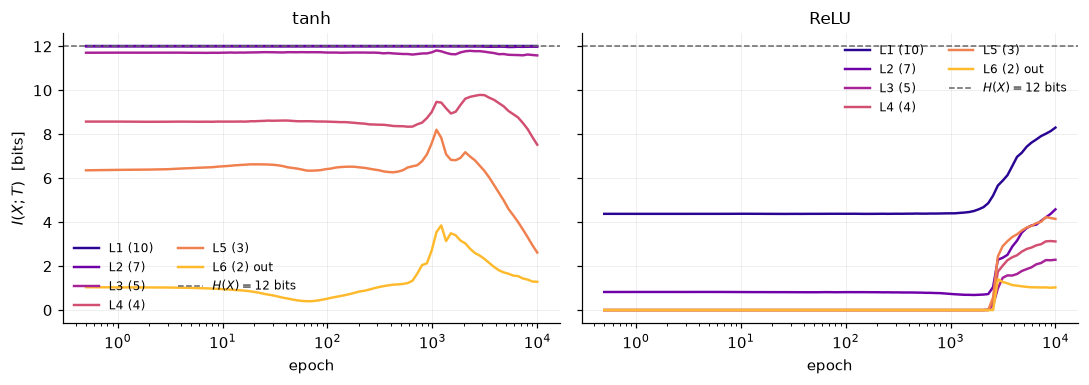

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6), sharey=True)
plotting.layer_curves(log_tanh.epochs, ixt_tanh, ax=axes[0], layer_names=log_tanh.layer_names,
                      ylabel=r"$I(X;T)$  [bits]", title="tanh", hline=12.0,
                      hline_label=r"$H(X)=12$ bits")
plotting.layer_curves(log_relu.epochs, ixt_relu, ax=axes[1], layer_names=log_relu.layer_names,
                      ylabel="", title="ReLU", hline=12.0, hline_label=r"$H(X)=12$ bits")
fig.tight_layout()
plotting.save(fig, "fig01_IXT_vs_epoch", FIGDIR)
plt.show()

## 2.3 Appendix E — why: the activations saturate

The proposed mechanism is testable directly. Histogram each layer's activity over training:

* In the **tanh** network the mass migrates into the extreme bins near $\pm 1$. Once a unit
  is saturated, a wide range of inputs produce the same binned value, so $H(T)$ — which
  *is* $I(X;T)$ here — collapses.
* In the **ReLU** network a roughly constant fraction of activations sits at exactly zero,
  while the non-zero activations disperse without bound. Dispersal raises entropy.

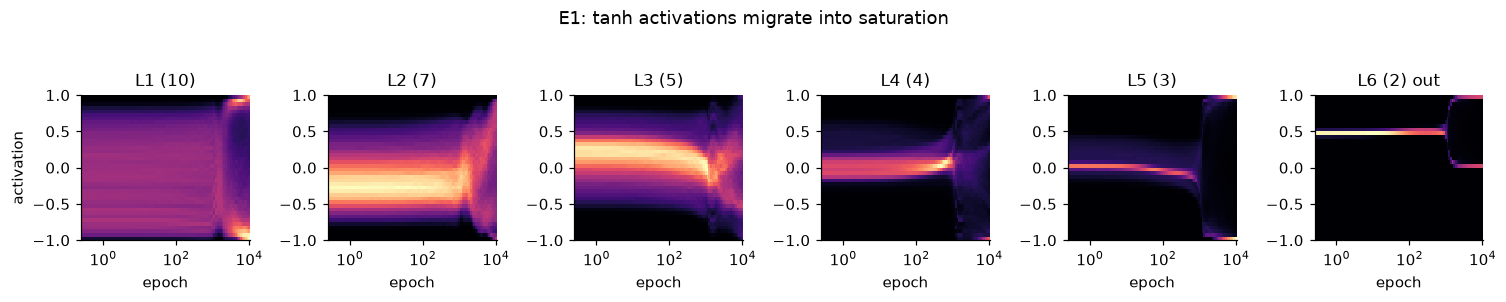

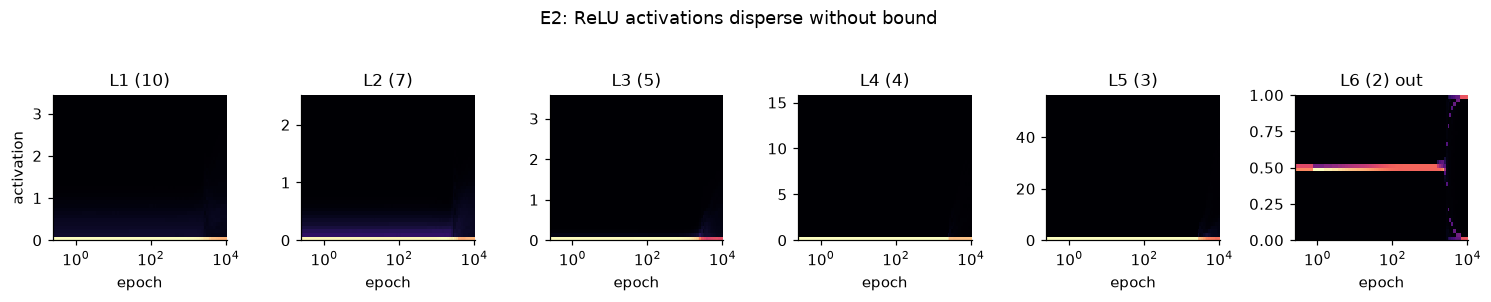

In [9]:
fig = plotting.activation_histograms(
    log_tanh.epochs, log_tanh.activations, layer_names=log_tanh.layer_names,
    bounds=(-1.0, 1.0), n_bins=40, title="E1: tanh activations migrate into saturation")
plotting.save(fig, "figE1_tanh_activations", FIGDIR)
plt.show()

fig = plotting.activation_histograms(
    log_relu.epochs, log_relu.activations, layer_names=log_relu.layer_names,
    bounds=None, n_bins=40, title="E2: ReLU activations disperse without bound")
plotting.save(fig, "figE2_relu_activations", FIGDIR)
plt.show()

In [10]:
def saturated_fraction(acts, thresh=0.98):
    return float(np.mean(np.abs(acts) > thresh))

print("fraction of tanh activations with |h| > 0.98 (i.e. saturated)")
print(f"{'layer':12s} {'epoch 0':>10s} {'final':>10s}")
print("-" * 34)
for j, ln in enumerate(log_tanh.layer_names[:-1]):
    a0 = saturated_fraction(log_tanh.activations[0][j])
    a1 = saturated_fraction(log_tanh.activations[-1][j])
    print(f"{ln:12s} {a0:10.3f} {a1:10.3f}")

print()
print("fraction of ReLU activations exactly at zero (the 'off' state)")
print(f"{'layer':12s} {'epoch 0':>10s} {'final':>10s}   max activation (final)")
print("-" * 60)
for j, ln in enumerate(log_relu.layer_names[:-1]):
    z0 = float(np.mean(log_relu.activations[0][j] == 0))
    z1 = float(np.mean(log_relu.activations[-1][j] == 0))
    mx = float(log_relu.activations[-1][j].max())
    print(f"{ln:12s} {z0:10.3f} {z1:10.3f} {mx:24.2f}")

fraction of tanh activations with |h| > 0.98 (i.e. saturated)
layer           epoch 0      final
----------------------------------
L1 (10)           0.001      0.039
L2 (7)            0.000      0.006
L3 (5)            0.000      0.015
L4 (4)            0.000      0.170
L5 (3)            0.000      0.754

fraction of ReLU activations exactly at zero (the 'off' state)
layer           epoch 0      final   max activation (final)
------------------------------------------------------------
L1 (10)           0.583      0.505                     3.44
L2 (7)            0.457      0.458                     2.51
L3 (5)            0.852      0.547                     3.58
L4 (4)            0.814      0.672                    15.81
L5 (3)            0.631      0.669                    56.31


## 2.4 Appendix B — is it just a bad estimator?

No. The binning estimator is crude, so the obvious objection is that a better estimator
would tell a different story. Appendix B checks this with two standard non-parametric
estimators, and notebook 3 removes estimation error entirely by going to linear networks.

### B.1 Kernel density estimator (Kolchinsky & Tracey)

Assume $T = h + \epsilon$ with $\epsilon\sim\mathcal{N}(0,\sigma^2 I)$, $\sigma^2 = 0.1$.
Then $p(T)$ is *exactly* a mixture of $P$ Gaussians centred on the $h_i$, and pairwise
distances give bounds on its entropy (equations B.1–B.6):

$$I(T;X) \;\le\; -\frac1P\sum_i \log \frac1P \sum_j
   \exp\Big(-\tfrac12 \tfrac{\|h_i - h_j\|^2}{\sigma^2}\Big).$$

In [11]:
ACTS = ["tanh", "relu", "softsign", "softplus"]
N_SEEDS = 5

kde_planes = {act: tishby_plane_averaged(act, labels, n_seeds=N_SEEDS,
                                         estimator="kde", var=0.1)
              for act in ACTS}
for act, pl in kde_planes.items():
    print(f"{act:9s}: {pl.summary()}")

tanh     : [kde, n=5] compression per layer -> L1 (10): +0.00, L2 (7): +0.00, L3 (5): +0.00, L4 (4): +0.39, L5 (3): +0.69, L6 (2) out: +0.19
relu     : [kde, n=5] compression per layer -> L1 (10): +0.00, L2 (7): +0.00, L3 (5): +0.00, L4 (4): +0.00, L5 (3): +0.00, L6 (2) out: +0.10
softsign : [kde, n=5] compression per layer -> L1 (10): +0.00, L2 (7): +0.00, L3 (5): +0.00, L4 (4): +0.00, L5 (3): +0.11, L6 (2) out: +0.09
softplus : [kde, n=5] compression per layer -> L1 (10): +0.00, L2 (7): +0.00, L3 (5): +0.00, L4 (4): +0.00, L5 (3): +0.00, L6 (2) out: +0.01


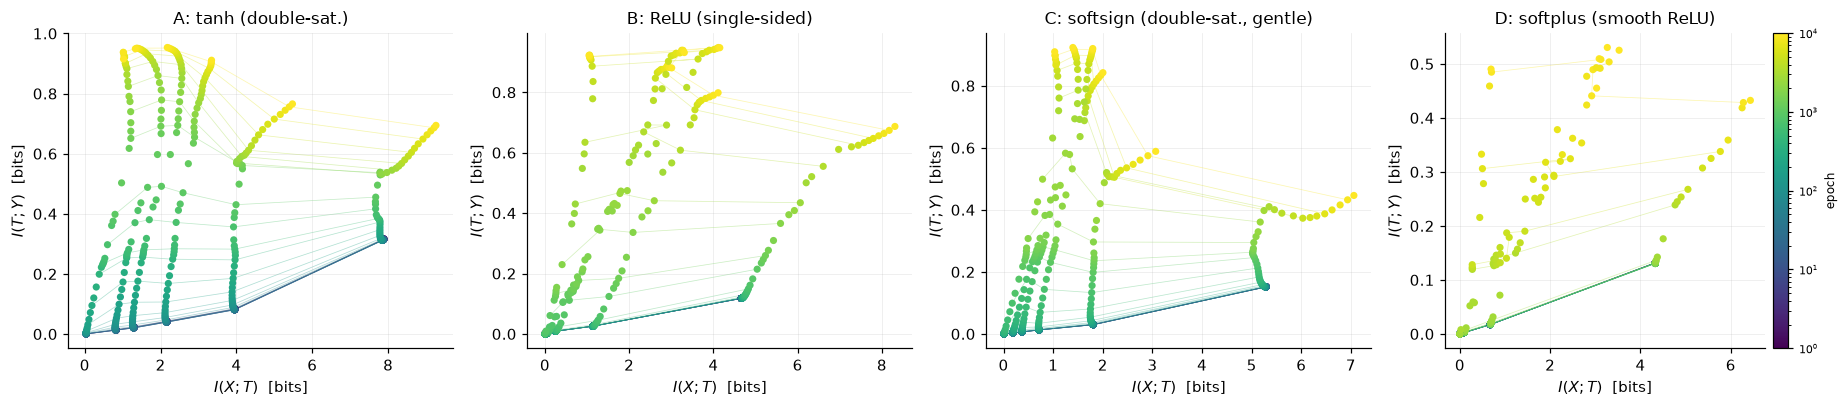

activation    double-saturating?   max compression [bits]
----------------------------------------------------------
tanh                         yes                     0.69
relu                          no                     0.10
softsign                     yes                     0.11
softplus                      no                     0.01


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(17.0, 3.8))
titles = {"tanh": "A: tanh (double-sat.)", "relu": "B: ReLU (single-sided)",
          "softsign": "C: softsign (double-sat., gentle)", "softplus": "D: softplus (smooth ReLU)"}
for ax, act in zip(axes, ACTS):
    pl = kde_planes[act]
    plotting.information_plane(pl.epochs, pl.I_XT, pl.I_TY, ax=ax, title=titles[act],
                               layer_names=pl.layer_names, colorbar=(act == ACTS[-1]))
fig.tight_layout()
plotting.save(fig, "figB1_kde_activations", FIGDIR)
plt.show()

print(f"{'activation':11s} {'double-saturating?':>20s} {'max compression [bits]':>24s}")
print("-" * 58)
double = {"tanh": "yes", "softsign": "yes", "relu": "no", "softplus": "no"}
for act in ACTS:
    print(f"{act:11s} {double[act]:>20s} {max(kde_planes[act].compression):>24.2f}")

The KDE estimator reproduces the same split, and refines it: **softsign** is
double-saturating but approaches its asymptotes more slowly than tanh, and it compresses
correspondingly less. **Softplus** is a smoothed ReLU and behaves like one. The ordering
tracks saturation behaviour, not anything about the learning algorithm.

### B.3 Kraskov $k$-NN estimator — and a caveat the paper does not mention

The $k$-NN route avoids committing to $\sigma^2$. If $T = h + Z$ with $Z$ independent of
$X$, then

$$I(T;X) = H(T) - H(T\mid X) = H(T) - H(Z) = H(T) - c$$

for a **constant** $c$. So compression can be read off $H(T)$ alone, whatever the noise
level: falling entropy means compression.

There is a problem, though, and it bites exactly one of our two networks.

In [13]:
from ibdl.estimators.kraskov import duplicate_fraction

kras = {act: kraskov_entropy_curve(act, n_seeds=N_SEEDS) for act in ["tanh", "relu"]}

print("fraction of activation vectors that are EXACT duplicates of another")
print(f"{'layer':10s} {'tanh @0':>9s} {'tanh end':>9s} {'ReLU @0':>9s} {'ReLU end':>9s}")
print("-" * 50)
for j in range(5):
    t0 = duplicate_fraction(log_tanh.activations[0][j])
    t1 = duplicate_fraction(log_tanh.activations[-1][j])
    r0 = duplicate_fraction(log_relu.activations[0][j])
    r1 = duplicate_fraction(log_relu.activations[-1][j])
    print(f"L{j + 1:<9d} {t0:>9.3f} {t1:>9.3f} {r0:>9.3f} {r1:>9.3f}")

fraction of activation vectors that are EXACT duplicates of another
layer        tanh @0  tanh end   ReLU @0  ReLU end
--------------------------------------------------
L1             0.000     0.000     0.002     0.000
L2             0.000     0.000     0.002     0.000
L3             0.000     0.000     0.446     0.325
L4             0.000     0.000     0.446     0.353
L5             0.000     0.000     0.446     0.502


**A third to a half of the ReLU layers' activation vectors are bit-identical** (44.6% at
initialisation, 32–50% at the end of training), because a ReLU unit that is off outputs
*exactly* zero and whole units switch off together. The tanh network has none, at any layer,
at any point in training.

This breaks the estimator. Kozachenko–Leonenko assumes an absolutely continuous
distribution; a ReLU layer's output has an **atom at zero**, so it is a mixed
discrete–continuous distribution for which differential entropy is not defined. Operationally,
when $r_i = 0$ the $\epsilon$ guard in equation (B.10) takes over and each duplicated point
contributes $(d/P)\log\epsilon \approx -36.8 d/P$ nats. The resulting number tracks *how many
points coincide*, not how spread out the representation is.

The paper introduces $\epsilon = 10^{-16}$ to "prevent infinite terms" but does not note
that the estimate is then meaningless in that regime. So we read the tanh panel, and treat
the ReLU panel as a diagnostic of the estimator rather than of the network.

That is a quantitative claim, and it is checkable: if the guard really has taken over, then
a layer of dimension $d$ with a duplicate fraction $f$ should return roughly
$d\,f\log_2\epsilon$ bits **from the guard alone**, before the data contributes anything.
We test that below.

> **What this argument is *not*.** It is not "the numbers are large and negative, therefore
> wrong". A differential entropy is allowed to be very negative — a distribution that
> concentrates has one, which is exactly why the saturating tanh layers legitimately reach
> $-20$ bits and below. The question is only whether the number is a function of the data or
> of $\epsilon$.

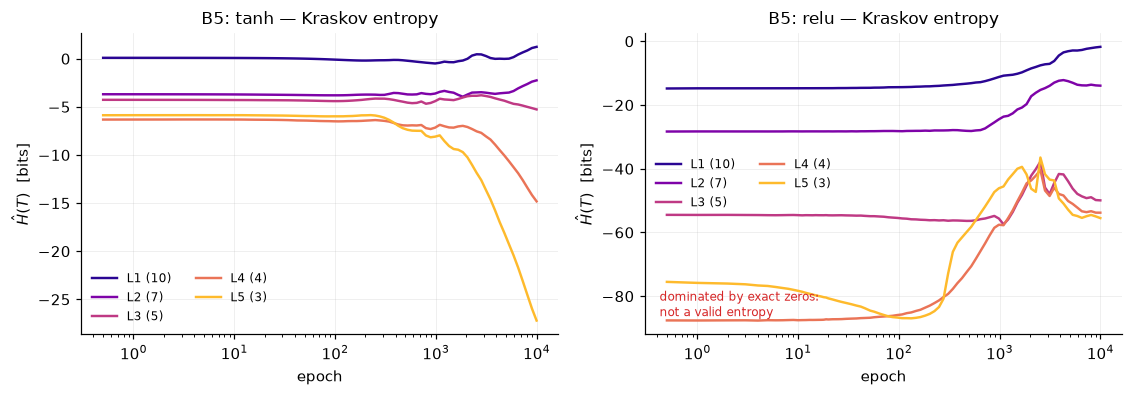

tanh entropy drop from peak per layer: [ 0.    0.    1.47  8.51 21.34]
  -> layers 4 and 5 lose 8.5 and 21.3 bits: clear compression,
     agreeing with the binning and KDE estimators.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.7))
for ax, act in zip(axes, ["tanh", "relu"]):
    ep, H = kras[act]
    plotting.layer_curves(ep, H, ax=ax, layer_names=log_tanh.layer_names[:-1],
                          ylabel=r"$\hat{H}(T)$  [bits]",
                          title=f"B5: {act} — Kraskov entropy")
axes[1].text(0.03, 0.06,
             "dominated by exact zeros:\nnot a valid entropy",
             transform=axes[1].transAxes, fontsize=8, color="#d62728")
fig.tight_layout()
plotting.save(fig, "figB5_kraskov_entropy", FIGDIR)
plt.show()

ep, H = kras["tanh"]
d = H.max(0) - H[-1]
print(f"tanh entropy drop from peak per layer: {np.round(d, 2)}")
print(f"  -> layers 4 and 5 lose {d[3]:.1f} and {d[4]:.1f} bits: clear compression,")
print("     agreeing with the binning and KDE estimators.")

### Is the ReLU estimate a function of the data, or of $\epsilon$?

Predict each layer's entropy from its **duplicate count alone** and compare with what the
estimator actually returned. (Single seed here, so that the duplicate fractions and the
entropies come from the same run.)

In [15]:
from ibdl.estimators.kraskov import entropy_kraskov

print(f"{'':7s} {'layer':10s} {'d':>3s} {'duplicates':>11s} {'measured H':>12s} "
      f"{'eps-guard alone':>17s}")
print("-" * 66)
for name, log in [("tanh", log_tanh), ("relu", log_relu)]:
    for j, ln in enumerate(log.layer_names[:-1]):
        a = log.activations[-1][j]
        f, dim = duplicate_fraction(a), a.shape[1]
        guard = dim * f * np.log2(1e-16)      # (d/P) * sum over the duplicated points
        print(f"{name:7s} {ln:10s} {dim:>3d} {f:>11.3f} {entropy_kraskov(a):>12.1f} "
              f"{guard:>17.1f}")
    print()
print("tanh: no duplicates anywhere, so the guard never engages. Its large negative values")
print("      are a genuine differential entropy -- a saturating layer really does concentrate.")
print()
print("ReLU: for layers 3-5 the guard term ALONE reproduces the measured value to within a")
print("      few bits. The estimator is reporting eps, not the data. And because the")
print("      duplicate count changes over training, so does the 'entropy' -- which is the")
print("      whole of the apparent ReLU 'compression' in figure B5.")

        layer        d  duplicates   measured H   eps-guard alone
------------------------------------------------------------------
tanh    L1 (10)     10       0.000          1.5              -0.0
tanh    L2 (7)       7       0.000         -2.3              -0.0
tanh    L3 (5)       5       0.000         -4.5              -0.0
tanh    L4 (4)       4       0.000        -11.1              -0.0
tanh    L5 (3)       3       0.000        -23.9              -0.0

relu    L1 (10)     10       0.000         -5.9              -0.0
relu    L2 (7)       7       0.000        -10.9              -0.0
relu    L3 (5)       5       0.325        -92.0             -86.4
relu    L4 (4)       4       0.353        -81.9             -75.0
relu    L5 (3)       3       0.502        -75.0             -80.0

tanh: no duplicates anywhere, so the guard never engages. Its large negative values
      are a genuine differential entropy -- a saturating layer really does concentrate.

ReLU: for layers 3-5 the guard t

## 2.5 Appendix C — the bins decide the answer

Notebook 1 made this point analytically. Here it is on the trained network: keep the
network, the data and the training run *completely fixed*, and change only the bin edges
from evenly spaced in **activation** to evenly spaced in **net input**
($b_i \in \tanh(\mathrm{linspace}(-50,50,N))$). The compression phase disappears
(figure C2).

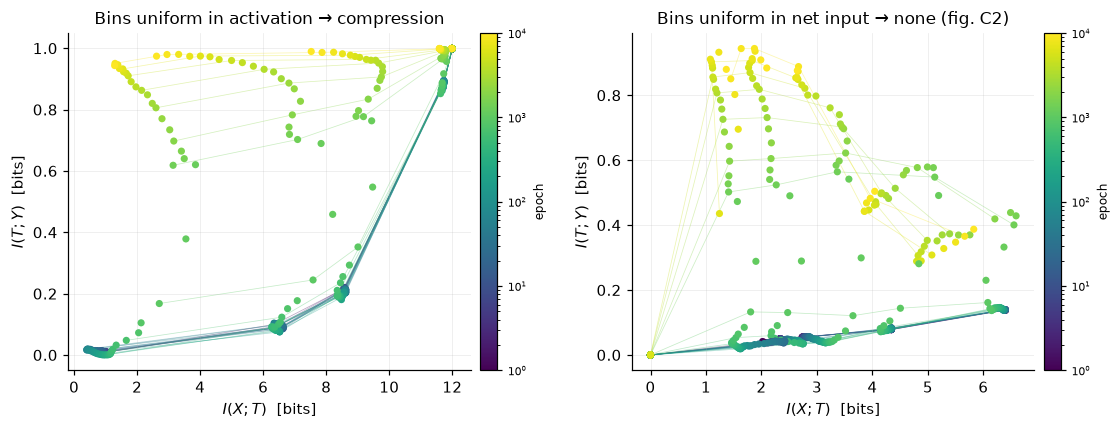

SAME network, SAME weights, SAME training run — only the bin edges differ.
layer         uniform-in-activation   uniform-in-net-input
----------------------------------------------------------
L1 (10)                    0.00 bits               0.76 bits
L2 (7)                     0.02 bits               1.15 bits
L3 (5)                     0.23 bits               1.15 bits
L4 (4)                     2.27 bits               0.77 bits
L5 (3)                     5.59 bits               0.32 bits
L6 (2) out                 2.56 bits               0.22 bits


In [16]:
plane_ni = tishby_plane(cfg_tanh, labels, estimator="binning", scheme="net_input")
ixt_ni, ity_ni = plane_ni.I_XT, plane_ni.I_TY

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
plotting.information_plane(log_tanh.epochs, ixt_tanh, ity_tanh, ax=axes[0],
                           title="Bins uniform in activation → compression",
                           layer_names=log_tanh.layer_names)
plotting.information_plane(log_tanh.epochs, ixt_ni, ity_ni, ax=axes[1],
                           title="Bins uniform in net input → none (fig. C2)",
                           layer_names=log_tanh.layer_names)
fig.tight_layout()
plotting.save(fig, "figC2_binning_changes_conclusion", FIGDIR)
plt.show()

print("SAME network, SAME weights, SAME training run — only the bin edges differ.")
print(f"{'layer':12s} {'uniform-in-activation':>22s} {'uniform-in-net-input':>22s}")
print("-" * 58)
for j, ln in enumerate(log_tanh.layer_names):
    print(f"{ln:12s} {ixt_tanh[:, j].max() - ixt_tanh[-1, j]:>18.2f} bits "
          f"{ixt_ni[:, j].max() - ixt_ni[-1, j]:>18.2f} bits")

### Figure C3 — binning at machine precision

A real network on real hardware *is* finite precision, but at roughly $2^{32}$ levels per
unit, not 30. Bin that finely and every one of the 4096 patterns gets its own code, so
$I(X;T) = \log_2 P = 12$ bits — pinned, with essentially no dynamics whatever.

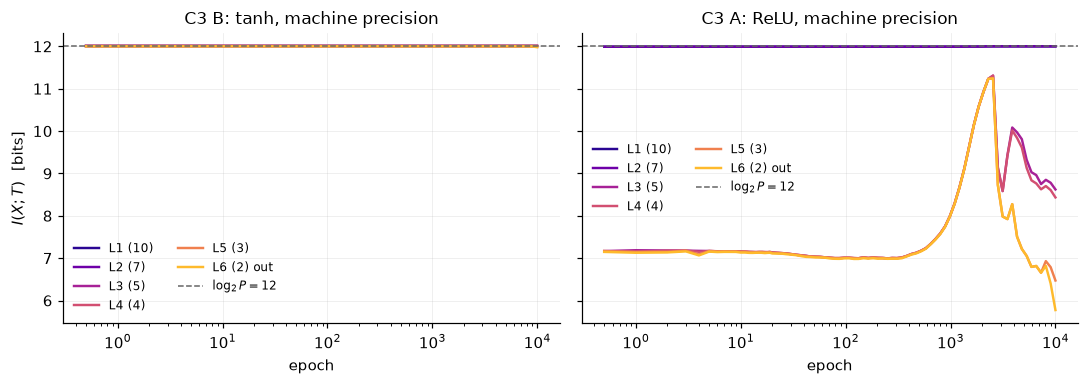

At machine precision the information is pinned at log2(4096) = 12 bits:
  tanh final : [12.   12.   12.   12.   12.   11.98]
  ReLU final : [12.    12.     8.622  8.434  6.473  5.775]


In [17]:
ixt_mp = tishby_plane(cfg_tanh, labels, estimator="binning", scheme="exact").I_XT
ixt_mp_relu = tishby_plane(cfg_relu, labels, estimator="binning", scheme="exact").I_XT

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6), sharey=True)
plotting.layer_curves(log_tanh.epochs, ixt_mp, ax=axes[0], layer_names=log_tanh.layer_names,
                      ylabel=r"$I(X;T)$  [bits]", title="C3 B: tanh, machine precision",
                      hline=12.0, hline_label=r"$\log_2 P = 12$")
plotting.layer_curves(log_relu.epochs, ixt_mp_relu, ax=axes[1], layer_names=log_relu.layer_names,
                      ylabel="", title="C3 A: ReLU, machine precision",
                      hline=12.0, hline_label=r"$\log_2 P = 12$")
fig.tight_layout()
plotting.save(fig, "figC3_machine_precision", FIGDIR)
plt.show()

print("At machine precision the information is pinned at log2(4096) = 12 bits:")
print(f"  tanh final : {np.round(ixt_mp[-1], 3)}")
print(f"  ReLU final : {np.round(ixt_mp_relu[-1], 3)}")

## Takeaways

1. The two-phase information-plane picture **replicates** for tanh — the original result is
   not a coding error.
2. Changing one string, `"tanh"` → `"relu"`, removes the compression phase entirely while
   the network trains just as well. Compression is therefore not a general property of deep
   learning.
3. The one ReLU layer that *does* compress is the sigmoidal output layer — the mechanism
   predicting its own exception.
4. Two independent estimators (binning and the KDE bounds) agree, so this is not an
   estimator artefact; notebook 3 confirms it decisively with *exact* information. The
   Kraskov $k$-NN estimator agrees for tanh but is **invalid for ReLU**, whose atom at zero
   makes ~45% of activation vectors identical and hands the estimate over to the
   $\epsilon$ guard — a caveat the paper's appendix B.3 does not raise.
5. Holding the network fixed and changing only the **bin edges** (App. C) or the **bin
   resolution** (fig. C3) turns the compression phase on and off. The quantity being
   plotted is a joint property of the network *and* an arbitrary analysis choice.

Next: [`04_sgd_vs_bgd.ipynb`](04_sgd_vs_bgd.ipynb) — is compression caused by SGD noise?